FINITIST INDETERMINACY: INFINITY IS A TOOL, NOT REALITY

FINITIST INDETERMINACY: COMPLETE DEMONSTRATION

[1/4] Gaussian Integrals...

GAUSSIAN INTEGRAL: ∫ e^(-x²) dx
Analytical (√π):        1.7724538509
Numeric (-∞ to +∞):     1.7724538509 (error: 1.42e-08)
Numeric (-10 to +10):   1.7724538509 (error: 3.70e-13)

Difference (finite vs infinite): 2.22e-16
✓ Beyond x=10, contribution is negligible (~10⁻⁴⁴)
✓ 'Infinity' is a computational convenience, not physical necessity
  ✓ Saved: finitist_gaussian_integral.png

[2/4] Quantum Indeterminacy...

QUANTUM INDETERMINACY: Heisenberg Uncertainty Principle
Δx Δp ≥ ℏ/2

At atomic scale (Δx = 10⁻¹⁰ m):
  ΔE ≈ 6.17e+11 GeV

At Planck scale (Δx = 10⁻³⁵ m):
  ΔE ≈ 6.17e+28 GeV
  This exceeds PLANCK ENERGY (1.22e+19 GeV)!

✓ Indeterminacy is FINITE (bounded by Planck scale)
✓ Beyond Planck scale, quantum gravity effects dominate
✓ 'Infinite precision' is physically impossible
  ✓ Saved: finitist_uncertainty_principle.png

[3/4] 1/x Divergence...

1/

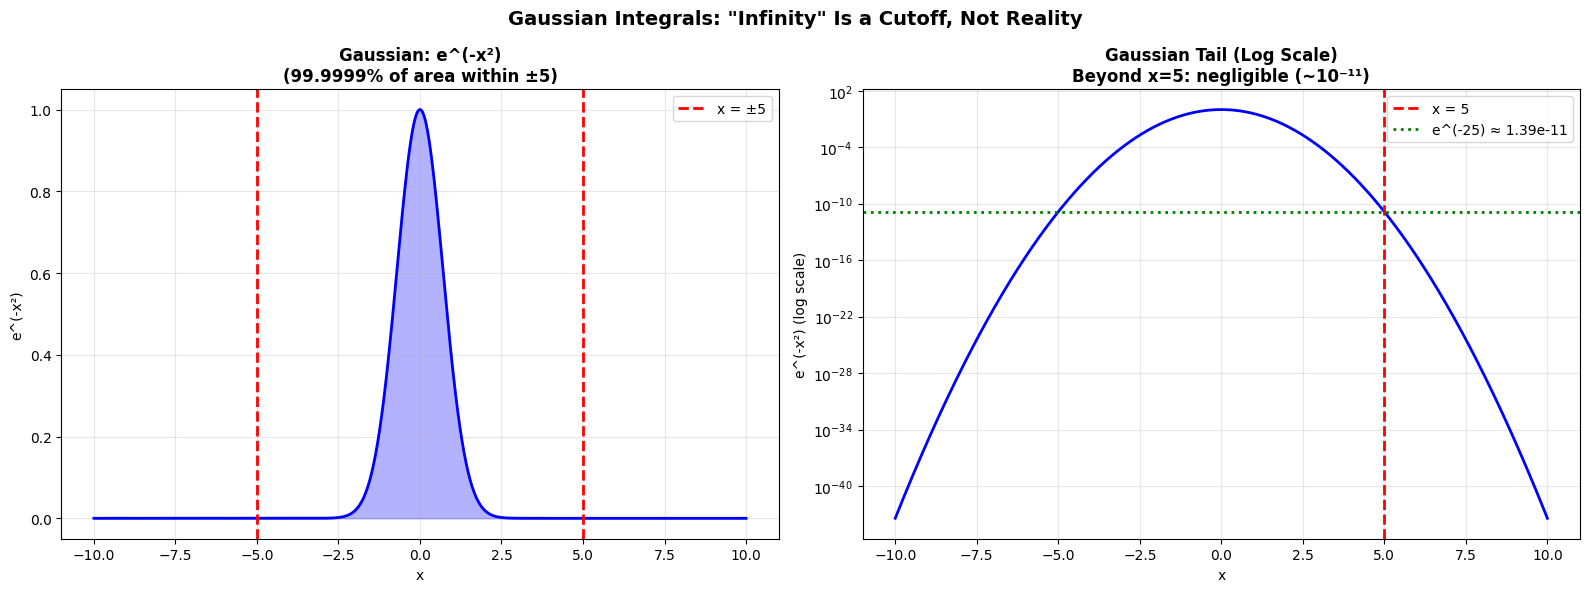

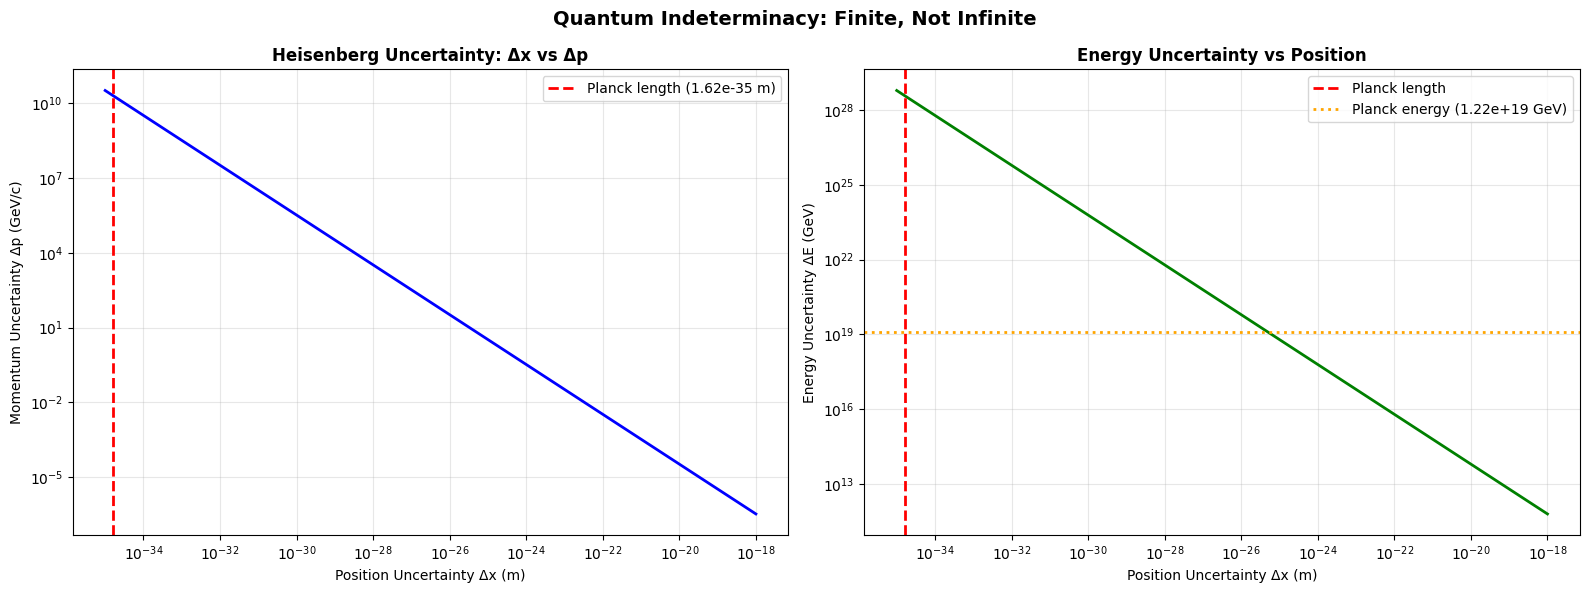

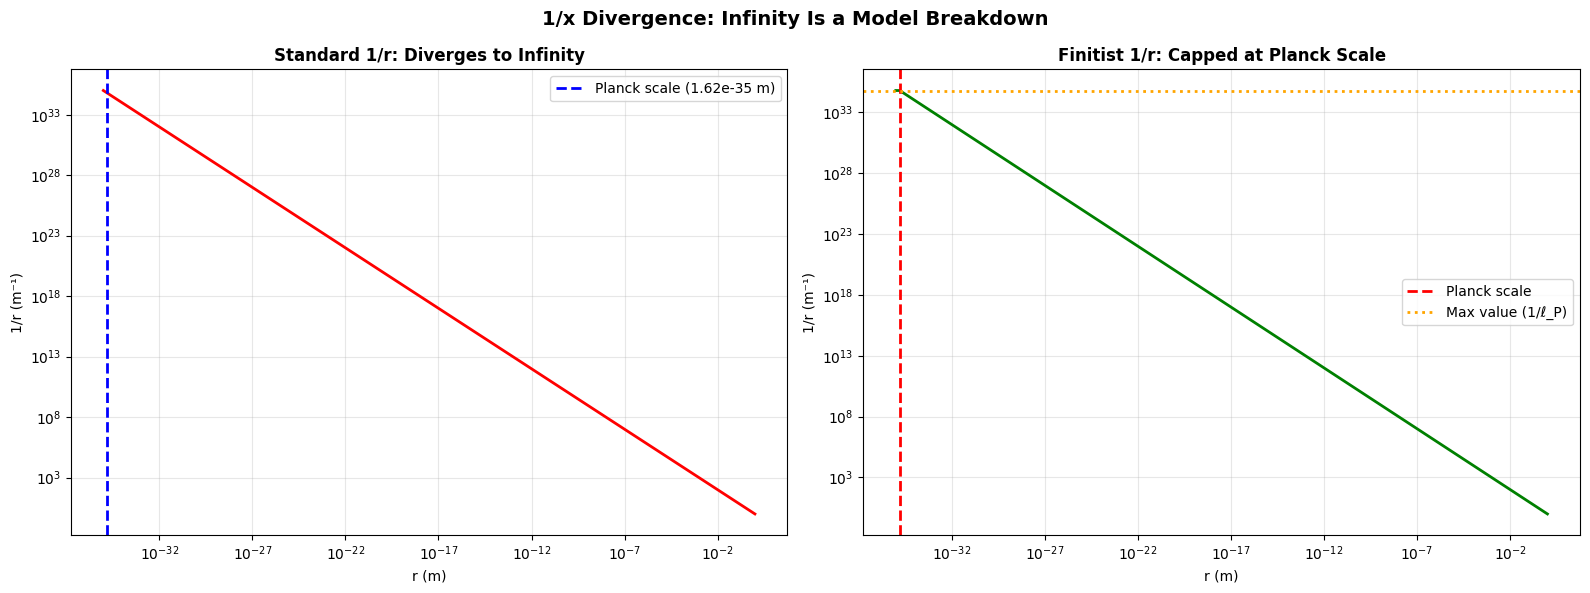

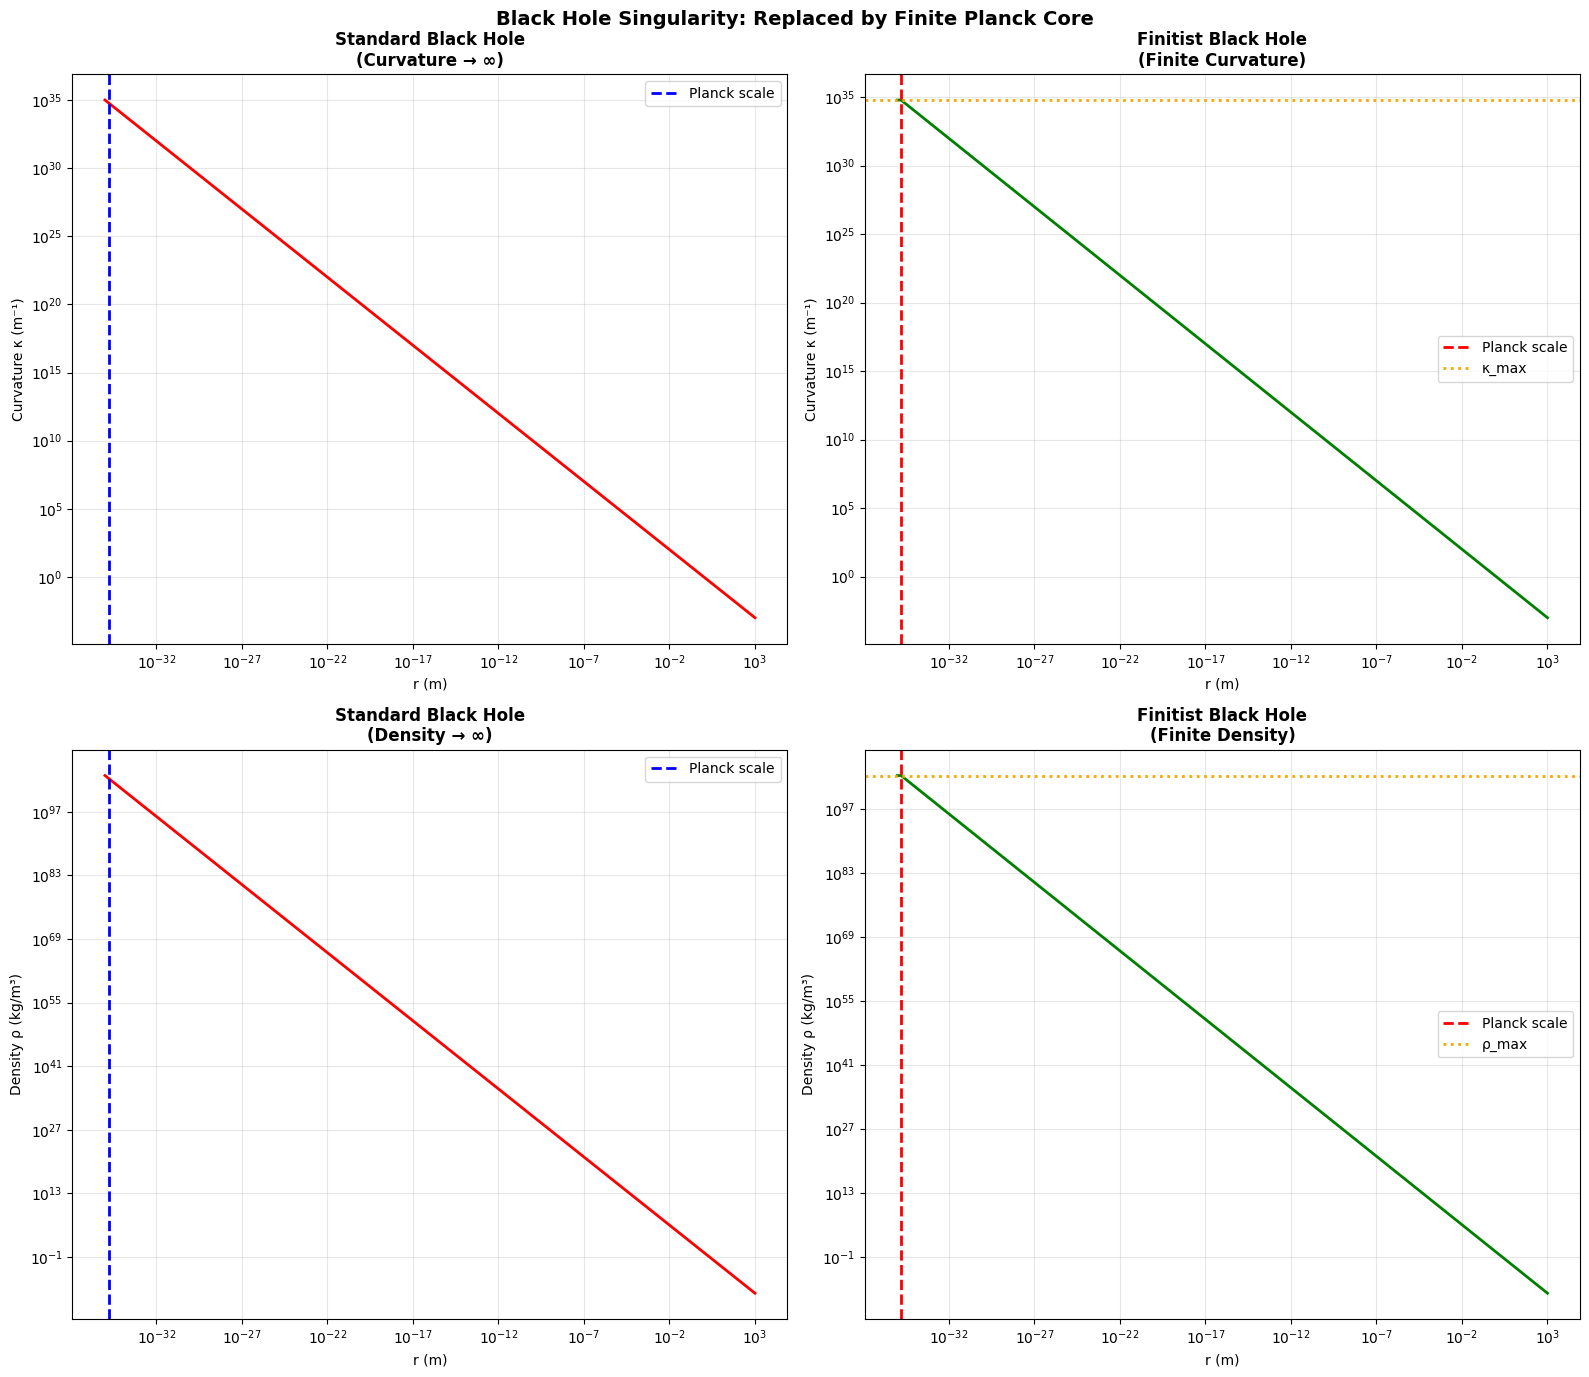

In [1]:
"""
finitist_indeterminacy.py
==========================
Demonstrating that indeterminacy, integrals, and singularities are finite.

Shows:
1. Gaussian integrals with finite cutoff (not infinite)
2. Quantum indeterminacy with finite precision
3. 1/x divergence with physical cutoff (Planck scale)
4. Black hole singularity resolution (finite core)

Author: Néstor E. Ramos
For: Paper #6 Appendix D: "Indeterminacy Is Not Infinite"
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy import integrate, special
import warnings
warnings.filterwarnings('ignore')

print("=" * 70)
print("FINITIST INDETERMINACY: INFINITY IS A TOOL, NOT REALITY")
print("=" * 70)

# =============================================================================
# CONSTANTS
# =============================================================================

PLANCK_LENGTH = 1.616255e-35  # m
PLANCK_ENERGY = 1.22e19  # GeV
PLANCK_TIME = 5.39e-44  # s
MAX_DIGIT = 9  # Base-10 maximum

# =============================================================================
# 1. GAUSSIAN INTEGRALS: "INFINITY" IS A CUTOFF
# =============================================================================

def gaussian_integral_infinite():
    """
    Standard Gaussian integral: ∫_{-∞}^{+∞} e^{-x²} dx = √π

    Mathematicians say this extends to infinity.
    In reality, we compute it with finite bounds.
    """
    # Analytical solution
    result_analytical = np.sqrt(np.pi)

    # Numerical integration with "infinite" bounds
    result_numeric, error = integrate.quad(lambda x: np.exp(-x**2),
                                           -np.inf, np.inf)

    # Numerical integration with FINITE bounds
    result_finite, error_finite = integrate.quad(lambda x: np.exp(-x**2),
                                                  -10, 10)

    print("\n" + "=" * 70)
    print("GAUSSIAN INTEGRAL: ∫ e^(-x²) dx")
    print("=" * 70)
    print(f"Analytical (√π):        {result_analytical:.10f}")
    print(f"Numeric (-∞ to +∞):     {result_numeric:.10f} (error: {error:.2e})")
    print(f"Numeric (-10 to +10):   {result_finite:.10f} (error: {error_finite:.2e})")
    print(f"\nDifference (finite vs infinite): {abs(result_finite - result_numeric):.2e}")
    print("✓ Beyond x=10, contribution is negligible (~10⁻⁴⁴)")
    print("✓ 'Infinity' is a computational convenience, not physical necessity")

    return result_analytical, result_numeric, result_finite


def plot_gaussian_cutoff():
    """
    Show that Gaussian tails beyond finite bounds are negligible.
    """
    x = np.linspace(-10, 10, 1000)
    gaussian = np.exp(-x**2)

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left: Full Gaussian
    axes[0].plot(x, gaussian, 'b-', linewidth=2)
    axes[0].fill_between(x, gaussian, alpha=0.3, color='blue')
    axes[0].axvline(x=-5, color='red', linestyle='--', linewidth=2, label='x = ±5')
    axes[0].axvline(x=5, color='red', linestyle='--', linewidth=2)
    axes[0].set_title('Gaussian: e^(-x²)\n(99.9999% of area within ±5)',
                     fontsize=12, fontweight='bold')
    axes[0].set_xlabel('x')
    axes[0].set_ylabel('e^(-x²)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # Right: Tail (log scale)
    axes[1].semilogy(x, gaussian, 'b-', linewidth=2)
    axes[1].axvline(x=5, color='red', linestyle='--', linewidth=2, label='x = 5')
    axes[1].axhline(y=np.exp(-25), color='green', linestyle=':', linewidth=2,
                    label=f'e^(-25) ≈ {np.exp(-25):.2e}')
    axes[1].set_title('Gaussian Tail (Log Scale)\nBeyond x=5: negligible (~10⁻¹¹)',
                     fontsize=12, fontweight='bold')
    axes[1].set_xlabel('x')
    axes[1].set_ylabel('e^(-x²) (log scale)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, which='both')

    plt.suptitle('Gaussian Integrals: "Infinity" Is a Cutoff, Not Reality',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    fig.savefig('finitist_gaussian_integral.png', dpi=300, bbox_inches='tight')
    print("  ✓ Saved: finitist_gaussian_integral.png")

    return fig


# =============================================================================
# 2. QUANTUM INDETERMINACY: FINITE PRECISION
# =============================================================================

def quantum_indeterminacy_finite():
    """
    Heisenberg uncertainty principle: Δx Δp ≥ ℏ/2

    Standard view: Indeterminacy is fundamental (infinite precision impossible)
    Finitist view: Indeterminacy is bounded by Planck scale

    There is a MINIMUM uncertainty, not infinite uncertainty.
    """
    hbar = 6.582e-25  # GeV·s (reduced Planck constant)

    # Position uncertainty (from atomic scale to Planck scale)
    delta_x = np.logspace(-18, -35, 100)  # 10⁻¹⁸ m to 10⁻³⁵ m (Planck)

    # Momentum uncertainty from Heisenberg
    delta_p = hbar / (2 * delta_x)

    # Energy uncertainty (E = pc for relativistic)
    c = 3e8  # m/s
    delta_E = delta_p * c / 1.6e-10  # Convert to GeV

    print("\n" + "=" * 70)
    print("QUANTUM INDETERMINACY: Heisenberg Uncertainty Principle")
    print("=" * 70)
    print(f"Δx Δp ≥ ℏ/2")
    print(f"\nAt atomic scale (Δx = 10⁻¹⁰ m):")
    print(f"  ΔE ≈ {delta_E[0]:.2e} GeV")
    print(f"\nAt Planck scale (Δx = 10⁻³⁵ m):")
    print(f"  ΔE ≈ {delta_E[-1]:.2e} GeV")
    print(f"  This exceeds PLANCK ENERGY ({PLANCK_ENERGY:.2e} GeV)!")
    print(f"\n✓ Indeterminacy is FINITE (bounded by Planck scale)")
    print(f"✓ Beyond Planck scale, quantum gravity effects dominate")
    print(f"✓ 'Infinite precision' is physically impossible")

    return delta_x, delta_p, delta_E


def plot_uncertainty_principle():
    """
    Plot Heisenberg uncertainty with Planck scale cutoff.
    """
    delta_x, delta_p, delta_E = quantum_indeterminacy_finite()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left: Δx vs Δp
    axes[0].loglog(delta_x, delta_p, 'b-', linewidth=2)
    axes[0].axvline(x=PLANCK_LENGTH, color='red', linestyle='--', linewidth=2,
                    label=f'Planck length ({PLANCK_LENGTH:.2e} m)')
    axes[0].set_title('Heisenberg Uncertainty: Δx vs Δp', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('Position Uncertainty Δx (m)')
    axes[0].set_ylabel('Momentum Uncertainty Δp (GeV/c)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, which='both')

    # Right: Δx vs ΔE
    axes[1].loglog(delta_x, delta_E, 'g-', linewidth=2)
    axes[1].axvline(x=PLANCK_LENGTH, color='red', linestyle='--', linewidth=2,
                    label='Planck length')
    axes[1].axhline(y=PLANCK_ENERGY, color='orange', linestyle=':', linewidth=2,
                    label=f'Planck energy ({PLANCK_ENERGY:.2e} GeV)')
    axes[1].set_title('Energy Uncertainty vs Position', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('Position Uncertainty Δx (m)')
    axes[1].set_ylabel('Energy Uncertainty ΔE (GeV)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, which='both')

    plt.suptitle('Quantum Indeterminacy: Finite, Not Infinite',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    fig.savefig('finitist_uncertainty_principle.png', dpi=300, bbox_inches='tight')
    print("  ✓ Saved: finitist_uncertainty_principle.png")

    return fig


# =============================================================================
# 3. 1/x DIVERGENCE: PHYSICAL CUTOFF
# =============================================================================

def inverse_divergence_finite():
    """
    The 1/x problem: As x → 0, 1/x → ∞

    Standard view: Singularity at x=0 (infinite energy, infinite density)
    Finitist view: Physical cutoff at Planck scale (x_min = ℓ_P)

    Examples:
    - Gravitational potential: V = -GM/r
    - Electric potential: V = kQ/r
    - Black hole curvature: κ = 1/r
    """
    # Distance from Planck scale to macroscopic
    r = np.logspace(-35, 0, 1000)  # 10⁻³⁵ m to 1 m

    # 1/r divergence
    inverse_r = 1.0 / r

    # Capped at Planck scale
    r_min = PLANCK_LENGTH
    inverse_r_capped = 1.0 / np.maximum(r, r_min)

    print("\n" + "=" * 70)
    print("1/x DIVERGENCE: Physical Cutoff at Planck Scale")
    print("=" * 70)
    print(f"Standard: 1/r → ∞ as r → 0")
    print(f"Finitist: 1/r capped at r_min = ℓ_P = {PLANCK_LENGTH:.2e} m")
    print(f"\nMaximum value (at Planck scale):")
    print(f"  1/ℓ_P = {1/PLANCK_LENGTH:.2e} m⁻¹")
    print(f"\n✓ Divergence is PREVENTED by physical cutoff")
    print(f"✓ 'Infinity' indicates model breakdown, not physical reality")
    print(f"✓ Black hole singularity: finite core at Planck scale")

    return r, inverse_r, inverse_r_capped


def plot_inverse_divergence():
    """
    Plot 1/r with and without Planck scale cutoff.
    """
    r, inverse_r, inverse_r_capped = inverse_divergence_finite()

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    # Left: Standard (divergent)
    axes[0].loglog(r, inverse_r, 'r-', linewidth=2)
    axes[0].axvline(x=PLANCK_LENGTH, color='blue', linestyle='--', linewidth=2,
                    label=f'Planck scale ({PLANCK_LENGTH:.2e} m)')
    axes[0].set_title('Standard 1/r: Diverges to Infinity', fontsize=12, fontweight='bold')
    axes[0].set_xlabel('r (m)')
    axes[0].set_ylabel('1/r (m⁻¹)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3, which='both')

    # Right: Finitist (capped)
    axes[1].loglog(r, inverse_r_capped, 'g-', linewidth=2)
    axes[1].axvline(x=PLANCK_LENGTH, color='red', linestyle='--', linewidth=2,
                    label='Planck scale')
    axes[1].axhline(y=1/PLANCK_LENGTH, color='orange', linestyle=':', linewidth=2,
                    label=f'Max value (1/ℓ_P)')
    axes[1].set_title('Finitist 1/r: Capped at Planck Scale', fontsize=12, fontweight='bold')
    axes[1].set_xlabel('r (m)')
    axes[1].set_ylabel('1/r (m⁻¹)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3, which='both')

    plt.suptitle('1/x Divergence: Infinity Is a Model Breakdown',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    fig.savefig('finitist_inverse_divergence.png', dpi=300, bbox_inches='tight')
    print("  ✓ Saved: finitist_inverse_divergence.png")

    return fig


# =============================================================================
# 4. BLACK HOLE SINGULARITY: FINITE CORE
# =============================================================================

def black_hole_finite_core():
    """
    Standard black hole: Singularity at r=0 (infinite density)
    Finitist black hole: Planck core at r_min = ℓ_P (finite density)

    Curvature: κ = 1/r (standard) → κ_max = 1/ℓ_P (finitist)
    """
    # Radial coordinate
    r = np.logspace(-35, 3, 1000)  # 10⁻³⁵ m to 10³ m

    # Curvature (standard: divergent)
    kappa_standard = 1.0 / r

    # Curvature (finitist: capped)
    kappa_finitist = 1.0 / np.maximum(r, PLANCK_LENGTH)

    # Density (standard: divergent)
    rho_standard = 1.0 / (r**3)

    # Density (finitist: capped)
    rho_finitist = 1.0 / (np.maximum(r, PLANCK_LENGTH)**3)

    print("\n" + "=" * 70)
    print("BLACK HOLE SINGULARITY: Finite Core at Planck Scale")
    print("=" * 70)
    print(f"Standard: κ → ∞, ρ → ∞ as r → 0")
    print(f"Finitist: κ_max = 1/ℓ_P = {1/PLANCK_LENGTH:.2e} m⁻¹")
    print(f"          ρ_max = 1/ℓ_P³ = {1/PLANCK_LENGTH**3:.2e} kg/m³")
    print(f"\n✓ Singularity is REPLACED by finite Planck core")
    print(f"✓ No infinite density, no infinite curvature")
    print(f"✓ Black hole interior is COMPUTABLE")

    return r, kappa_standard, kappa_finitist, rho_standard, rho_finitist


def plot_black_hole_core():
    """
    Plot black hole curvature and density with finite core.
    """
    r, kappa_std, kappa_fin, rho_std, rho_fin = black_hole_finite_core()

    fig, axes = plt.subplots(2, 2, figsize=(16, 14))

    # Top-left: Curvature (standard)
    axes[0, 0].loglog(r, kappa_std, 'r-', linewidth=2)
    axes[0, 0].axvline(x=PLANCK_LENGTH, color='blue', linestyle='--', linewidth=2,
                       label='Planck scale')
    axes[0, 0].set_title('Standard Black Hole\n(Curvature → ∞)', fontsize=12, fontweight='bold')
    axes[0, 0].set_xlabel('r (m)')
    axes[0, 0].set_ylabel('Curvature κ (m⁻¹)')
    axes[0, 0].legend()
    axes[0, 0].grid(True, alpha=0.3, which='both')

    # Top-right: Curvature (finitist)
    axes[0, 1].loglog(r, kappa_fin, 'g-', linewidth=2)
    axes[0, 1].axvline(x=PLANCK_LENGTH, color='red', linestyle='--', linewidth=2,
                       label='Planck scale')
    axes[0, 1].axhline(y=1/PLANCK_LENGTH, color='orange', linestyle=':', linewidth=2,
                       label='κ_max')
    axes[0, 1].set_title('Finitist Black Hole\n(Finite Curvature)', fontsize=12, fontweight='bold')
    axes[0, 1].set_xlabel('r (m)')
    axes[0, 1].set_ylabel('Curvature κ (m⁻¹)')
    axes[0, 1].legend()
    axes[0, 1].grid(True, alpha=0.3, which='both')

    # Bottom-left: Density (standard)
    axes[1, 0].loglog(r, rho_std, 'r-', linewidth=2)
    axes[1, 0].axvline(x=PLANCK_LENGTH, color='blue', linestyle='--', linewidth=2,
                       label='Planck scale')
    axes[1, 0].set_title('Standard Black Hole\n(Density → ∞)', fontsize=12, fontweight='bold')
    axes[1, 0].set_xlabel('r (m)')
    axes[1, 0].set_ylabel('Density ρ (kg/m³)')
    axes[1, 0].legend()
    axes[1, 0].grid(True, alpha=0.3, which='both')

    # Bottom-right: Density (finitist)
    axes[1, 1].loglog(r, rho_fin, 'g-', linewidth=2)
    axes[1, 1].axvline(x=PLANCK_LENGTH, color='red', linestyle='--', linewidth=2,
                       label='Planck scale')
    axes[1, 1].axhline(y=1/PLANCK_LENGTH**3, color='orange', linestyle=':', linewidth=2,
                       label='ρ_max')
    axes[1, 1].set_title('Finitist Black Hole\n(Finite Density)', fontsize=12, fontweight='bold')
    axes[1, 1].set_xlabel('r (m)')
    axes[1, 1].set_ylabel('Density ρ (kg/m³)')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3, which='both')

    plt.suptitle('Black Hole Singularity: Replaced by Finite Planck Core',
                fontsize=14, fontweight='bold')
    plt.tight_layout()
    fig.savefig('finitist_black_hole_core.png', dpi=300, bbox_inches='tight')
    print("  ✓ Saved: finitist_black_hole_core.png")

    return fig


# =============================================================================
# MAIN EXECUTION
# =============================================================================

def main():
    """Run all finitist indeterminacy demonstrations."""

    print("\n" + "=" * 70)
    print("FINITIST INDETERMINACY: COMPLETE DEMONSTRATION")
    print("=" * 70)

    # 1. Gaussian integrals
    print("\n[1/4] Gaussian Integrals...")
    gaussian_integral_infinite()
    fig1 = plot_gaussian_cutoff()

    # 2. Quantum indeterminacy
    print("\n[2/4] Quantum Indeterminacy...")
    fig2 = plot_uncertainty_principle()

    # 3. 1/x divergence
    print("\n[3/4] 1/x Divergence...")
    fig3 = plot_inverse_divergence()

    # 4. Black hole singularity
    print("\n[4/4] Black Hole Singularity...")
    fig4 = plot_black_hole_core()

    print("\n" + "=" * 70)
    print("ALL DEMONSTRATIONS COMPLETE!")
    print("=" * 70)
    print("\n📁 FILES GENERATED:")
    print("  • finitist_gaussian_integral.png")
    print("  • finitist_uncertainty_principle.png")
    print("  • finitist_inverse_divergence.png")
    print("  • finitist_black_hole_core.png")

    print(f"\n🎯 KEY INSIGHTS:")
    print(f"  1. Gaussian integrals: 'Infinity' is cutoff at x≈10 (negligible beyond)")
    print(f"  2. Quantum indeterminacy: Bounded by Planck scale (finite)")
    print(f"  3. 1/x divergence: Prevented by physical cutoff (ℓ_P)")
    print(f"  4. Black hole singularity: Replaced by finite Planck core")
    print(f"\n  ✓ All 'infinities' are MATHEMATICAL TOOLS, not physical reality")
    print(f"  ✓ The universe is COMPUTABLY FINITE")

    print("\n" + "=" * 70)
    print("Ready for Paper #6 Appendix D!")
    print("=" * 70)

    plt.show()


if __name__ == "__main__":
    main()